# Course 3 - Applied Machine Learning Using Python
## Assignment 1: Introduction to Machine Learning with the Breast Cancer Dataset

### Overview
This assignment introduces the core sklearn workflow: load data, create a DataFrame, split into train/test sets, train a classifier, and evaluate it. The dataset used is the **Breast Cancer Wisconsin (Diagnostic)** dataset, a classic binary classification problem built into scikit-learn.

### Learning Objectives
- Load and explore a sklearn Bunch dataset
- Convert sklearn datasets to pandas DataFrames
- Perform train/test splits with `train_test_split`
- Train a k-Nearest Neighbors (kNN) classifier
- Predict class labels and compute accuracy

### Dataset
- **Source:** `sklearn.datasets.load_breast_cancer()`
- **Shape:** 569 samples x 30 features + 1 target column
- **Target:** 0 = malignant, 1 = benign
- **Features:** 30 numeric features (mean, error, and worst values for 10 measurements)

### Assignment Structure
| Question | Task |
|----------|------|
| Q0 (Example) | Count the number of features |
| Q1 | Convert dataset to a pandas DataFrame (569 x 31) |
| Q2 | Compute class distribution (malignant vs benign counts) |
| Q3 | Split DataFrame into X (features) and y (labels) |
| Q4 | Train/test split using `random_state=0` |
| Q5 | Fit a kNN classifier with k=1 |
| Q6 | Predict class label for a sample with mean feature values |
| Q7 | Predict labels for the full test set |
| Q8 | Compute mean accuracy on the test set |

---
_You are currently looking at **version 0.1** of this notebook._

# Assignment 1 - Introduction to Machine Learning

For this assignment, you will be using the Breast Cancer Wisconsin (Diagnostic) Database to create a classifier that can help diagnose patients. First, read through the description of the dataset (below).

### Does kNN Need to Be Trained?

kNN has **no training phase** in the traditional sense.

`knn.fit(X_train, y_train)` just stores the data in memory. No math happens. No weights are computed. It is equivalent to:

```python
self.X_train = X_train
self.y_train = y_train
```

All computation is **deferred to prediction time**:

```python
knn.predict(x_new)
# → compute distance from x_new to all stored training points
# → find k closest
# → return majority vote
```

---

#### Comparison: What `.fit()` Actually Does

| Model | What `.fit()` does |
|-------|-------------------|
| **kNN** | Stores data. Nothing else. |
| Linear regression | Solves `w = (XᵀX)⁻¹Xᵀy` — computes a weight vector |
| Neural network | Runs gradient descent for many epochs — updates millions of weights |
| Decision tree | Finds optimal splits across all features |

---

#### The Lazy Learner Tradeoff

Because kNN does no upfront work, it pays the cost at inference time instead:

| | kNN | Parametric models |
|--|-----|------------------|
| Training speed | Fast (just store data) | Slow (optimize weights) |
| Prediction speed | Slow (scan all training points) | Fast (one forward pass) |
| Memory | High (keep entire dataset) | Low (just store weights) |

This is why kNN is called a **lazy learner** — all the work happens at prediction time, not training time.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

print(cancer.DESCR) # Print the data set description

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

### What This Code Does
Loads the Breast Cancer Wisconsin dataset from sklearn's built-in datasets. `load_breast_cancer()` returns a Bunch object (dict-like) containing `.data` (feature matrix), `.target` (labels 0/1), `.feature_names`, and `.DESCR` (full description). Printing `cancer.DESCR` shows the dataset provenance, attribute descriptions, and class distribution.

The object returned by `load_breast_cancer()` is a scikit-learn Bunch object, which is similar to a dictionary.

In [2]:
cancer.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

### Question 0 (Example)

How many features does the breast cancer dataset have?

*This function should return an integer.*

In [3]:
def answer_zero():
    # Returns the number of features in the breast cancer dataset
    return len(cancer.feature_names)

answer_zero()

30

### Question 1

Scikit-learn works with lists, numpy arrays, scipy-sparse matrices, and pandas DataFrames, so converting the dataset to a DataFrame is not necessary for training this model. Using a DataFrame does however help make many things easier such as munging data, so let's practice creating a classifier with a pandas DataFrame. 



Convert the sklearn.dataset `cancer` to a DataFrame. 

*This function should return a `(569, 31)` DataFrame with * 

*columns = *

    ['mean radius', 'mean texture', 'mean perimeter', 'mean area',
    'mean smoothness', 'mean compactness', 'mean concavity',
    'mean concave points', 'mean symmetry', 'mean fractal dimension',
    'radius error', 'texture error', 'perimeter error', 'area error',
    'smoothness error', 'compactness error', 'concavity error',
    'concave points error', 'symmetry error', 'fractal dimension error',
    'worst radius', 'worst texture', 'worst perimeter', 'worst area',
    'worst smoothness', 'worst compactness', 'worst concavity',
    'worst concave points', 'worst symmetry', 'worst fractal dimension',
    'target']

*and index = *

    RangeIndex(start=0, stop=569, step=1)

In [4]:
def answer_one():
    # Combine feature data with target column into a single DataFrame
    cancerdf = pd.DataFrame(cancer.data, columns=cancer.feature_names)
    cancerdf['target'] = cancer.target
    return cancerdf

answer_one()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


### Question 2
What is the class distribution? (i.e. how many instances of `malignant` and how many `benign`?)

*This function should return a Series named `target` of length 2 with integer values and index =* `['malignant', 'benign']`

In [5]:
def answer_two():
    # Count instances of malignant (0) and benign (1) in the target column
    cancerdf = answer_one()
    malignant = (cancerdf['target'] == 0).sum()
    benign = (cancerdf['target'] == 1).sum()
    return pd.Series({'malignant': malignant, 'benign': benign}, name='target')

answer_two()

malignant    212
benign       357
Name: target, dtype: int64

### Question 3
Split the DataFrame into `X` (the data) and `y` (the labels).

*This function should return a tuple of length 2:* `(X, y)`*, where* 
* `X` *has shape* `(569, 30)`
* `y` *has shape* `(569,)`.

In [6]:
def answer_three():
    # Separate features (X) from labels (y)
    cancerdf = answer_one()
    X = cancerdf.iloc[:, :-1]   # all columns except 'target'
    y = cancerdf['target']
    return X, y

answer_three()

(     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
 0          17.99         10.38          122.80     1001.0          0.11840   
 1          20.57         17.77          132.90     1326.0          0.08474   
 2          19.69         21.25          130.00     1203.0          0.10960   
 3          11.42         20.38           77.58      386.1          0.14250   
 4          20.29         14.34          135.10     1297.0          0.10030   
 ..           ...           ...             ...        ...              ...   
 564        21.56         22.39          142.00     1479.0          0.11100   
 565        20.13         28.25          131.20     1261.0          0.09780   
 566        16.60         28.08          108.30      858.1          0.08455   
 567        20.60         29.33          140.10     1265.0          0.11780   
 568         7.76         24.54           47.92      181.0          0.05263   
 
      mean compactness  mean concavity  mean conca

### Question 4
Using `train_test_split`, split `X` and `y` into training and test sets `(X_train, X_test, y_train, and y_test)`.

**Set the random number generator state to 0 using `random_state=0` to make sure your results match the autograder!**

*This function should return a tuple of length 4:* `(X_train, X_test, y_train, y_test)`*, where* 
* `X_train` *has shape* `(426, 30)`
* `X_test` *has shape* `(143, 30)`
* `y_train` *has shape* `(426,)`
* `y_test` *has shape* `(143,)`

In [7]:
from sklearn.model_selection import train_test_split

def answer_four():
    # Split into 75% train / 25% test with a fixed random seed for reproducibility
    X, y = answer_three()
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
    return X_train, X_test, y_train, y_test

answer_four()

(     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
 293       11.850         17.46           75.54      432.7          0.08372   
 332       11.220         19.86           71.94      387.3          0.10540   
 565       20.130         28.25          131.20     1261.0          0.09780   
 278       13.590         17.84           86.24      572.3          0.07948   
 489       16.690         20.20          107.10      857.6          0.07497   
 ..           ...           ...             ...        ...              ...   
 277       18.810         19.98          120.90     1102.0          0.08923   
 9         12.460         24.04           83.97      475.9          0.11860   
 359        9.436         18.32           59.82      278.6          0.10090   
 192        9.720         18.22           60.73      288.1          0.06950   
 559       11.510         23.93           74.52      403.5          0.09261   
 
      mean compactness  mean concavity  mean conca

### Question 5
Using KNeighborsClassifier, fit a k-nearest neighbors (knn) classifier with `X_train`, `y_train` and using one nearest neighbor (`n_neighbors = 1`).

*This function should return a `sklearn.neighbors.classification.KNeighborsClassifier`.

In [8]:
from sklearn.neighbors import KNeighborsClassifier

def answer_five():
    # Train a 1-NN classifier on the training set
    X_train, X_test, y_train, y_test = answer_four()
    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_train, y_train)
    return knn

ans_five = answer_five()
ans_five

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [9]:
ans_five

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


### Question 6
Using your knn classifier, predict the class label using the mean value for each feature.

Hint: You can use `cancerdf.mean()[:-1].values.reshape(1, -1)` which gets the mean value for each feature, ignores the target column, and reshapes the data from 1 dimension to 2 (necessary for the precict method of KNeighborsClassifier).

In [16]:
def answer_six():
    # Predict the label for a sample whose features equal the dataset column means
    cancerdf = answer_one()
    knn = answer_five()
    mean_sample = cancerdf.mean()[:-1].values.reshape(1, -1)
    mean_sample_df = pd.DataFrame(mean_sample, columns= cancer.feature_names)
    return knn.predict(mean_sample_df)

answer_six()

array([1])

### Question 7
Using your knn classifier, predict the class labels for the test set `X_test`.

*This function should return a numpy array with shape `(143,)` and values either `0.0` or `1.0`.*

In [11]:
def answer_seven():
    # Predict class labels for all test samples
    X_train, X_test, y_train, y_test = answer_four()
    knn = answer_five()
    return knn.predict(X_test)

answer_seven()

array([1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0])

### Question 8
Find the score (mean accuracy) of your knn classifier using `X_test` and `y_test`.

*This function should return a float between 0 and 1*

In [12]:
def answer_eight():
    # Compute mean accuracy of the kNN classifier on the test set
    X_train, X_test, y_train, y_test = answer_four()
    knn = answer_five()
    return knn.score(X_test, y_test)

answer_eight()

0.916083916083916

### Approach: Accuracy Across k Values
This optional visualization plots kNN accuracy for k=1 through 25 on both training and test sets, split by class (malignant/benign). It reveals the bias-variance tradeoff: k=1 perfectly memorizes training data (overfitting) while higher k values generalize better to unseen samples.

### Optional plot

Try using the plotting function below to visualize the different predicition scores between train and test sets, as well as malignant and benign cells.

In [ ]:
def accuracy_plot():
    import matplotlib.pyplot as plt

    %matplotlib inline

    X_train, X_test, y_train, y_test = answer_four()

    train_mal = y_train == 0
    train_ben = y_train == 1
    test_mal  = y_test  == 0
    test_ben  = y_test  == 1

    k_range = range(1, 26)
    train_mal_scores, train_ben_scores = [], []
    test_mal_scores,  test_ben_scores  = [], []

    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)
        
        train_mal_scores.append(knn.score(X_train[train_mal], y_train[train_mal]))
        train_ben_scores.append(knn.score(X_train[train_ben], y_train[train_ben]))
        test_mal_scores.append(knn.score(X_test[test_mal],   y_test[test_mal]))
        test_ben_scores.append(knn.score(X_test[test_ben],   y_test[test_ben]))

    plt.figure(figsize=(10, 6))
    plt.plot(k_range, train_mal_scores, label='Train (Malignant)', linestyle='--')
    plt.plot(k_range, train_ben_scores, label='Train (Benign)',     linestyle='--')
    plt.plot(k_range, test_mal_scores,  label='Test (Malignant)')
    plt.plot(k_range, test_ben_scores,  label='Test (Benign)')
    plt.xlabel('k (n_neighbors)')
    plt.ylabel('Accuracy')
    plt.title('kNN Accuracy vs k — Train/Test by Class')
    plt.legend()
    plt.tight_layout()
    plt.show()

NameError: name 'X_train' is not defined

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
565        20.13         28.25          131.20     1261.0          0.09780   
489        16.69         20.20          107.10      857.6          0.07497   
65         14.78         23.94           97.40      668.3          0.11720   
126        13.61         24.69           87.76      572.6          0.09258   
392        15.49         19.97          102.40      744.7          0.11600   
..           ...           ...             ...        ...              ...   
72         17.20         24.52          114.20      929.4          0.10710   
87         19.02         24.59          122.00     1076.0          0.09029   
70         18.94         21.31          123.60     1130.0          0.09009   
277        18.81         19.98          120.90     1102.0          0.08923   
9          12.46         24.04           83.97      475.9          0.11860   

     mean compactness  mean concavity  mean concave points  mea

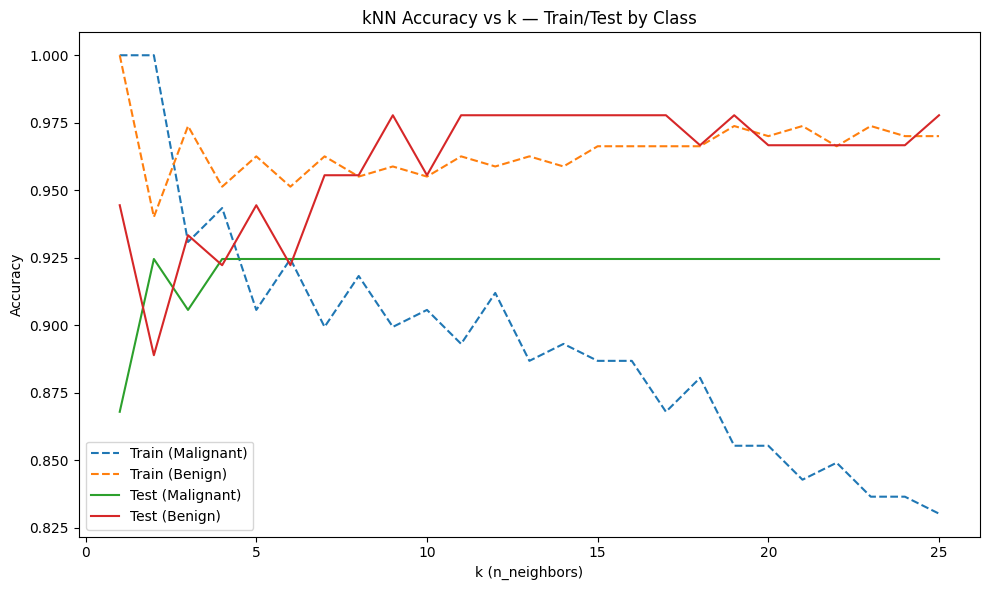

In [19]:
accuracy_plot()

### Bias-Variance Tradeoff

The bias-variance tradeoff is the tension between two sources of model error.

---

#### Why High k → High Bias

kNN prediction for a new point `x`:

```
ŷ = majority_vote({ y_i : x_i ∈ k nearest neighbors of x })
```

Large k pulls in **distant** neighbors — points far from `x` that may belong to a different local region. The prediction gets averaged/smoothed over a wide area.

**Bias = systematic error = E[ŷ] - f(x)**

Large k → prediction is majority vote in a large neighborhood → ignores local structure → prediction systematically wrong near decision boundaries. The model can't "see" fine-grained patterns.

---

#### Why Low k → High Variance

k=1 means: `ŷ = label of single closest training point`.

Any noise in that one neighbor's label corrupts the prediction. The decision boundary becomes jagged — it contorts around every training point.

**Variance = sensitivity to training data = E[(ŷ - E[ŷ])²]**

Small k → prediction driven by 1 (or few) noisy data points → different training sets produce wildly different boundaries → high variance.

---

#### The Mathematical Model

kNN is **non-parametric** — no weights are learned. Formally:

```
ŷ(x) = (1/k) Σ y_i    for x_i ∈ N_k(x)       ← regression
ŷ(x) = argmax_c |{y_i = c : x_i ∈ N_k(x)}|   ← classification
```

where `N_k(x)` = set of k training points closest to `x` by Euclidean distance:

```
d(x, x_i) = √( Σ (x_j - x_ij)² )   over all 30 features
```

---

#### What is Actually "Learned"?

**Nothing.** kNN is a **lazy learner** — training phase just stores all data:

| Phase | What happens |
|-------|-------------|
| "Training" | Store all (x_i, y_i) pairs in memory |
| Prediction | Compute distances to all stored points, find k nearest, vote |

No weight vector, no gradient descent, no optimization. The training data **is** the model.

Compare to parametric models:

```
Linear regression:  ŷ = w₀ + w₁x₁ + ... + w₃₀x₃₀  ← learns 31 weights
Neural network:     ŷ = f(Wx + b)                    ← learns millions of weights
kNN:                ŷ = vote(k nearest stored points) ← learns nothing; k is a hyperparameter
```

---

#### Summary

| k | Bias | Variance | Total Error |
|---|------|----------|-------------|
| k=1  | Low  | High | High (overfits)  |
| k=?  | Med  | Med  | Low (sweet spot) |
| k=25 | High | Low  | High (underfits) |

> **Total Error = Bias² + Variance + Irreducible Noise**

The peak of the test accuracy curve in the plot = optimal k = best bias-variance balance.

## Total Error = Bias² + Variance + Irreducible Noise

### Setup

True world: `y = f(x) + ε`
- `f(x)` = true signal
- `ε` = pure noise, `E[ε] = 0`, `Var[ε] = σ²`
- `f̂(x)` = your model (changes with each training set)

Error measured as **Expected MSE** over all possible training sets:

$$\text{Error} = \mathbb{E}\left[(y - \hat{f}(x))^2\right]$$

---

### Derivation — add/subtract `E[f̂(x)]`

```
y - f̂ = (y - f) + (f - E[f̂]) + (E[f̂] - f̂)
          ↑ noise    ↑ bias         ↑ variance term
```

Square it, take expectation. Cross terms with `ε` vanish (noise independent of model):

$$\mathbb{E}\left[(y - \hat{f})^2\right] = \underbrace{\sigma^2}_{\text{Irreducible}} + \underbrace{(f - \mathbb{E}[\hat{f}])^2}_{\text{Bias}^2} + \underbrace{\mathbb{E}\left[(\hat{f} - \mathbb{E}[\hat{f}])^2\right]}_{\text{Variance}}$$

---

### What each term means

| Term | Formula | What it captures |
|---|---|---|
| **Bias²** | $(\ \mathbb{E}[\hat{f}(x)] - f(x)\ )^2$ | Avg prediction vs truth — model wrong *on average* |
| **Variance** | $\mathbb{E}\left[(\hat{f}(x) - \mathbb{E}[\hat{f}(x)])^2\right]$ | Spread of predictions across datasets — model too sensitive to training data |
| **Irreducible noise** | $\sigma^2$ | Real-world noise in `y` itself — can't model it away |

---

### Why "errors"

Each term is a **squared deviation** contributing to MSE:

- **Bias²** — systematic error: model assumptions don't match true signal
- **Variance** — estimation error: overfitting, model chases noise in training data
- **σ²** — measurement/process noise: floor you can't beat regardless of model

**Trade-off:** Complex models → low bias, high variance. Simple models → high bias, low variance. σ² is unchanged by either.

| k | Bias | Variance | Total Error |
|---|------|----------|-------------|
| k=1  | Low  | High | High (overfits noise) |
| k=?  | Med  | Med  | Low (sweet spot)      |
| k=25 | High | Low  | High (underfits signal) |

### Decision Boundary Visualization

The **decision boundary** is the dividing line in feature space where the model switches its prediction from malignant → benign (or vice versa).

- **k=1**: boundary is jagged and irregular — contorts around every training point (high variance / overfitting)
- **High k**: boundary is smooth and coarse — ignores local structure (high bias / underfitting)

Since the dataset has 30 features, we can't plot the boundary directly. We use **PCA (Principal Component Analysis)** to compress 30 dimensions → 2 dimensions, then plot the boundary on that 2D projection.

PCA finds the 2 directions of maximum variance in the data — so the 2D plot captures as much structure as possible.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

%matplotlib inline

def plot_decision_boundary(k_values=[1, 5, 15]):
    X_train, X_test, y_train, y_test = answer_four()

    # Scale features — kNN is distance-based, so scale matters
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # Reduce to 2D with PCA for visualization
    pca = PCA(n_components=2)
    X_train_2d = pca.fit_transform(X_train_scaled)
    X_test_2d  = pca.transform(X_test_scaled)

    # Mesh grid over the 2D PCA space
    x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
    y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))

    fig, axes = plt.subplots(1, len(k_values), figsize=(6 * len(k_values), 5))

    for ax, k in zip(axes, k_values):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_2d, y_train)

        # Predict class for every point in the mesh
        Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

        # Background color = predicted class
        ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
        ax.contour(xx, yy, Z, colors='k', linewidths=0.5)

        # Training points
        ax.scatter(X_train_2d[y_train == 0, 0], X_train_2d[y_train == 0, 1],
                   c='red',   label='Train Malignant', edgecolors='k', s=40, alpha=0.7)
        ax.scatter(X_train_2d[y_train == 1, 0], X_train_2d[y_train == 1, 1],
                   c='green', label='Train Benign',    edgecolors='k', s=40, alpha=0.7)

        # Test points (larger markers)
        ax.scatter(X_test_2d[y_test == 0, 0], X_test_2d[y_test == 0, 1],
                   c='darkred',   marker='^', s=80, label='Test Malignant', edgecolors='k')
        ax.scatter(X_test_2d[y_test == 1, 0], X_test_2d[y_test == 1, 1],
                   c='darkgreen', marker='^', s=80, label='Test Benign',    edgecolors='k')

        acc = knn.score(X_test_2d, y_test)
        ax.set_title(f'k={k}  |  Test acc (2D PCA): {acc:.2f}')
        ax.set_xlabel('PCA Component 1')
        ax.set_ylabel('PCA Component 2')
        ax.legend(fontsize=7, loc='upper right')

    plt.suptitle('kNN Decision Boundary (PCA 2D projection)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

plot_decision_boundary(k_values=[1, 5, 15])